# imporitng library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.utils import to_categorical
from keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout

# Retrieving the images and their labels 

In [2]:
data=[]
labels=[]
classes=43
curr_path=os.getcwd()

for i in range(classes):
    path=os.path.join(curr_path,'Train',str(i))
    images=os.listdir(path)
    for a in images:
        try:
            image=Image.open(path+"\\"+a)
            image=image.resize((30,30))
            image=np.array(image)
            data.append(image)
            labels.append(i)
        except:
            print('Error loding image')

# converting lists into numpy array

In [3]:
data=np.array(data)
labels=np.array(labels)
print(data.shape,labels.shape)

(39209, 30, 30, 3) (39209,)


# Spliting training and testing dataset

In [4]:
x_train,x_test,y_train,y_test=train_test_split(data,labels,test_size=0.2,random_state=0)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


# Converting the labels into one hot encoding


In [5]:
y_train=to_categorical(y_train,43)
y_test=to_categorical(y_test,43)

# BUilding the model

In [8]:
model=Sequential()
model.add(Conv2D(filters=32,kernel_size=(5,5),activation='relu',input_shape=x_train.shape[1:]))
model.add(Conv2D(filters=32,kernel_size=(5,5),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43,activation='softmax'))

# compilation of model

In [10]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

epochs = 15
history = model.fit(x_train, y_train, batch_size=32, epochs=epochs, validation_data=(x_test, y_test))
model.save("trafic.h5")

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5291 - loss: 1.8488 - val_accuracy: 0.8650 - val_loss: 0.5130
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8023 - loss: 0.6735 - val_accuracy: 0.9348 - val_loss: 0.2393
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8851 - loss: 0.3951 - val_accuracy: 0.9629 - val_loss: 0.1283
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9168 - loss: 0.2919 - val_accuracy: 0.9722 - val_loss: 0.1079
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9355 - loss: 0.2282 - val_accuracy: 0.9774 - val_loss: 0.0770
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9352 - loss: 0.2291 - val_accuracy: 0.9727 - val_loss: 0.0921
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9425 - loss: 0.2114 - val_accuracy: 0.9770 - val_loss: 0.0770
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9434 - loss: 0.2117 - 

# plotting graph for accuracy

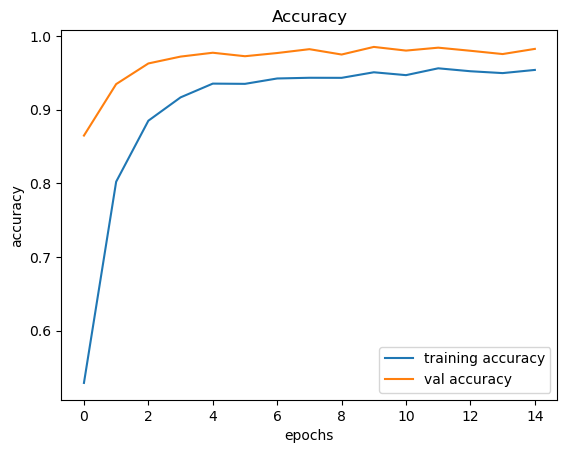

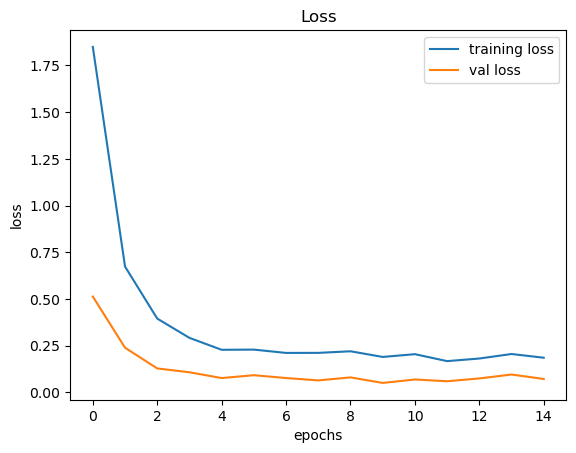

In [11]:
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


# Testing accuracy on test dataset

In [13]:
from sklearn.metrics import accuracy_score
# y_test=pd.read_csv('Test.csv')
# labels=y_test['ClassId'].values
# imgs=y_test['Path'].values

# data=[]

# for img in imgs:
#     image=Image.open(img)
#     image=image.resize((30,30))
#     data.append(np.array(image))

# x_test=np.array(data)

# pred=model.predict_classes(x_test)






y_test = pd.read_csv("Test.csv")

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data = []

for img in imgs:
    image = Image.open(img)
    image = image.resize((30, 30))
    data.append(np.array(image))

x_test = np.array(data)

# Normalize if you normalized your training data
x_test = x_test / 255.0

# Predict probabilities
pred = model.predict(x_test)

# Convert probabilities to class IDs
pred = np.argmax(pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(labels, pred))



395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.0166270783847981


# Accuracy with the test data

In [14]:

from sklearn.metrics import accuracy_score
print(accuracy_score(labels, pred))

0.0166270783847981
